In [4]:
from IPython.display import display, HTML

display(HTML("""
<style>
  @import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;600;700&display=swap');
  .cover {
    font-family: 'Inter', 'Segoe UI', Arial, sans-serif;
    background: linear-gradient(135deg, #1a1a2e 0%, #2E4057 50%, #048A81 100%);
    border-radius: 16px;
    padding: 48px 52px 40px;
    color: white;
    max-width: 1100px;
    margin: 0 auto;
    position: relative;
    overflow: hidden;
  }
  .cover::before {
    content: '';
    position: absolute;
    top: -60px; right: -60px;
    width: 280px; height: 280px;
    background: rgba(255,255,255,0.04);
    border-radius: 50%;
  }
  .cover::after {
    content: '';
    position: absolute;
    bottom: -80px; left: 30%;
    width: 350px; height: 350px;
    background: rgba(84,198,235,0.07);
    border-radius: 50%;
  }
  .cover-eyebrow {
    font-size: 11px; font-weight: 600; letter-spacing: 2.5px;
    text-transform: uppercase; color: #54C6EB; margin-bottom: 12px;
  }
  .cover-title {
    font-size: 32px; font-weight: 700; line-height: 1.2;
    margin: 0 0 6px 0;
  }
  .cover-subtitle {
    font-size: 15px; font-weight: 300; opacity: 0.75;
    margin: 0 0 32px 0;
  }
  .cover-divider {
    border: none; border-top: 1px solid rgba(255,255,255,0.18);
    margin: 0 0 28px 0;
  }
  .cover-stats {
    display: grid;
    grid-template-columns: repeat(4, 1fr);
    gap: 0;
  }
  .cover-stat {
    padding: 0 24px 0 0;
    border-right: 1px solid rgba(255,255,255,0.15);
  }
  .cover-stat:first-child { padding-left: 0; }
  .cover-stat:last-child  { border-right: none; }
  .cover-stat-val  { font-size: 28px; font-weight: 700; color: #E8C547; }
  .cover-stat-label{ font-size: 11px; color: rgba(255,255,255,0.6);
                     text-transform: uppercase; letter-spacing: .8px; margin-top: 3px; }
  .cover-pills {
    display: flex; flex-wrap: wrap; gap: 8px; margin-top: 30px;
  }
  .cover-pill {
    background: rgba(255,255,255,0.12);
    border: 1px solid rgba(255,255,255,0.2);
    border-radius: 20px;
    padding: 5px 14px;
    font-size: 11px; font-weight: 500; color: rgba(255,255,255,0.85);
    backdrop-filter: blur(4px);
  }
  .cover-goal {
    margin-top: 24px;
    background: rgba(255,255,255,0.08);
    border-left: 4px solid #54C6EB;
    border-radius: 0 8px 8px 0;
    padding: 12px 18px;
    font-size: 13px;
    color: rgba(255,255,255,0.85);
    line-height: 1.6;
  }
  .cover-meta {
    margin-top: 24px;
    display: flex; justify-content: space-between; align-items: center;
    font-size: 11px; color: rgba(255,255,255,0.45);
  }
</style>

<div class="cover">
  <div class="cover-eyebrow"> Orpa Tateyama &nbsp;·&nbsp; Marketing Intelligence</div>
  <h1 class="cover-title">Marketing Campaign Analytics</h1>
  <p class="cover-subtitle">Executive Report &amp; Strategic Intelligence Dashboard</p>
  <hr class="cover-divider">

  <div class="cover-stats">
    <div class="cover-stat" style="padding-left:0">
      <div class="cover-stat-val">2,213</div>
      <div class="cover-stat-label">Customers Analysed</div>
    </div>
    <div class="cover-stat">
      <div class="cover-stat-val">29</div>
      <div class="cover-stat-label">Features</div>
    </div>
    <div class="cover-stat">
      <div class="cover-stat-val">5</div>
      <div class="cover-stat-label">Marketing Campaigns</div>
    </div>
    <div class="cover-stat">
      <div class="cover-stat-val">6</div>
      <div class="cover-stat-label">Spend Categories</div>
    </div>
  </div>

  <div class="cover-pills">
    <span class="cover-pill">&#127919; RFM Segmentation</span>
    <span class="cover-pill">&#128202; K-Means Clustering</span>
    <span class="cover-pill">&#129302; Random Forest ML</span>
    <span class="cover-pill">&#128176; CLV Analysis</span>
    <span class="cover-pill">&#128200; PCA Dimensionality Reduction</span>
    <span class="cover-pill">&#9989; Welch's t-test</span>
    <span class="cover-pill">&#128233; Campaign ROI Modelling</span>
  </div>

  <div class="cover-goal">
    <strong style="color:#54C6EB">Objective:</strong>&nbsp;
    Identify high-value customer segments, optimise campaign targeting through ML-driven propensity scoring,
    quantify customer lifetime value by cohort, and deliver a prioritised action plan to maximise ROI
    on future direct marketing spend.
  </div>

  <div class="cover-meta">
  </div>
</div>
"""))


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, silhouette_score, ConfusionMatrixDisplay)
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
import scipy.stats as stats

# Corporate colour palette
PALETTE = ['#2E4057', '#048A81', '#54C6EB', '#EF8354', '#E8C547', '#A8DADC']
sns.set_theme(style='whitegrid', palette=PALETTE)
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans', 'axes.titlesize': 13})
print("✓ Libraries loaded")


✓ Libraries loaded


## 1. Data Loading & Quality Audit

In [6]:
df = pd.read_csv(r'marketing_campaign.csv', sep='\t')

print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nDtypes:\n{df.dtypes.value_counts()}")
df.head(3)


Shape: (2240, 29)

Missing values:
Income    24
dtype: int64

Dtypes:
int64      25
object      3
float64     1
Name: count, dtype: int64


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0


## 2. Data Cleaning & Feature Engineering

In [7]:
df = df.dropna(subset=['Income'])  # 24 missing incomes — MCAR, safe to drop

df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)
snapshot_date = df['Dt_Customer'].max() + pd.Timedelta(days=1)

# ── Age & Tenure ─────────────────────────────────────────────────────────────
df['Age'] = 2024 - df['Year_Birth']
df['Tenure_Days'] = (snapshot_date - df['Dt_Customer']).dt.days
df = df[df['Age'] < 90]  # remove 3 implausible birth years

# ── Household ────────────────────────────────────────────────────────────────
df['Children']    = df['Kidhome'] + df['Teenhome']
df['Has_Children'] = (df['Children'] > 0).astype(int)
df['Family_Size'] = df['Marital_Status'].map(
    {'Married': 2, 'Together': 2, 'Single': 1, 'Divorced': 1, 'Widow': 1,
     'Absurd': 1, 'YOLO': 1}) + df['Children']

# ── Spending ─────────────────────────────────────────────────────────────────
spend_cols = ['MntWines','MntFruits','MntMeatProducts',
              'MntFishProducts','MntSweetProducts','MntGoldProds']
df['TotalSpend']    = df[spend_cols].sum(axis=1)
df['AvgSpendPerDay'] = df['TotalSpend'] / df['Tenure_Days'].replace(0, np.nan)

# ── Purchases & Channels ─────────────────────────────────────────────────────
purchase_cols = ['NumWebPurchases','NumCatalogPurchases',
                 'NumStorePurchases','NumDealsPurchases']
df['TotalPurchases'] = df[purchase_cols].sum(axis=1)
df['DealRatio']      = df['NumDealsPurchases'] / df['TotalPurchases'].replace(0, np.nan)
df['PreferredChannel'] = df[['NumWebPurchases','NumCatalogPurchases',
                               'NumStorePurchases']].idxmax(axis=1).str.replace('Num','').str.replace('Purchases','')

# ── Campaign engagement ───────────────────────────────────────────────────────
cmp_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5']
df['CampaignsAccepted'] = df[cmp_cols].sum(axis=1)
df['EverAccepted']      = (df['CampaignsAccepted'] > 0).astype(int)

# ── Education simplification ─────────────────────────────────────────────────
edu_map = {'Basic': 'Low', '2n Cycle': 'Medium',
           'Graduation': 'High', 'Master': 'Very High', 'PhD': 'Very High'}
df['Education_Level'] = df['Education'].map(edu_map)

print(f"Clean dataset: {df.shape[0]} customers, {df.shape[1]} features")
df[['Age','Tenure_Days','TotalSpend','TotalPurchases','CampaignsAccepted']].describe().round(1)


Clean dataset: 2213 customers, 42 features


,Age,Tenure_Days,TotalSpend,TotalPurchases,CampaignsAccepted
count,2213.0,2213.0,2213.0,2213.0,2213.0
mean,55.1,354.7,607.0,14.9,0.3
std,11.7,202.5,602.5,7.7,0.7
min,28.0,1.0,5.0,0.0,0.0
25%,47.0,181.0,69.0,8.0,0.0
50%,54.0,357.0,397.0,15.0,0.0
75%,65.0,530.0,1048.0,21.0,0.0
max,84.0,700.0,2525.0,44.0,4.0


## 3. Exploratory Data Analysis — Customer Demographics

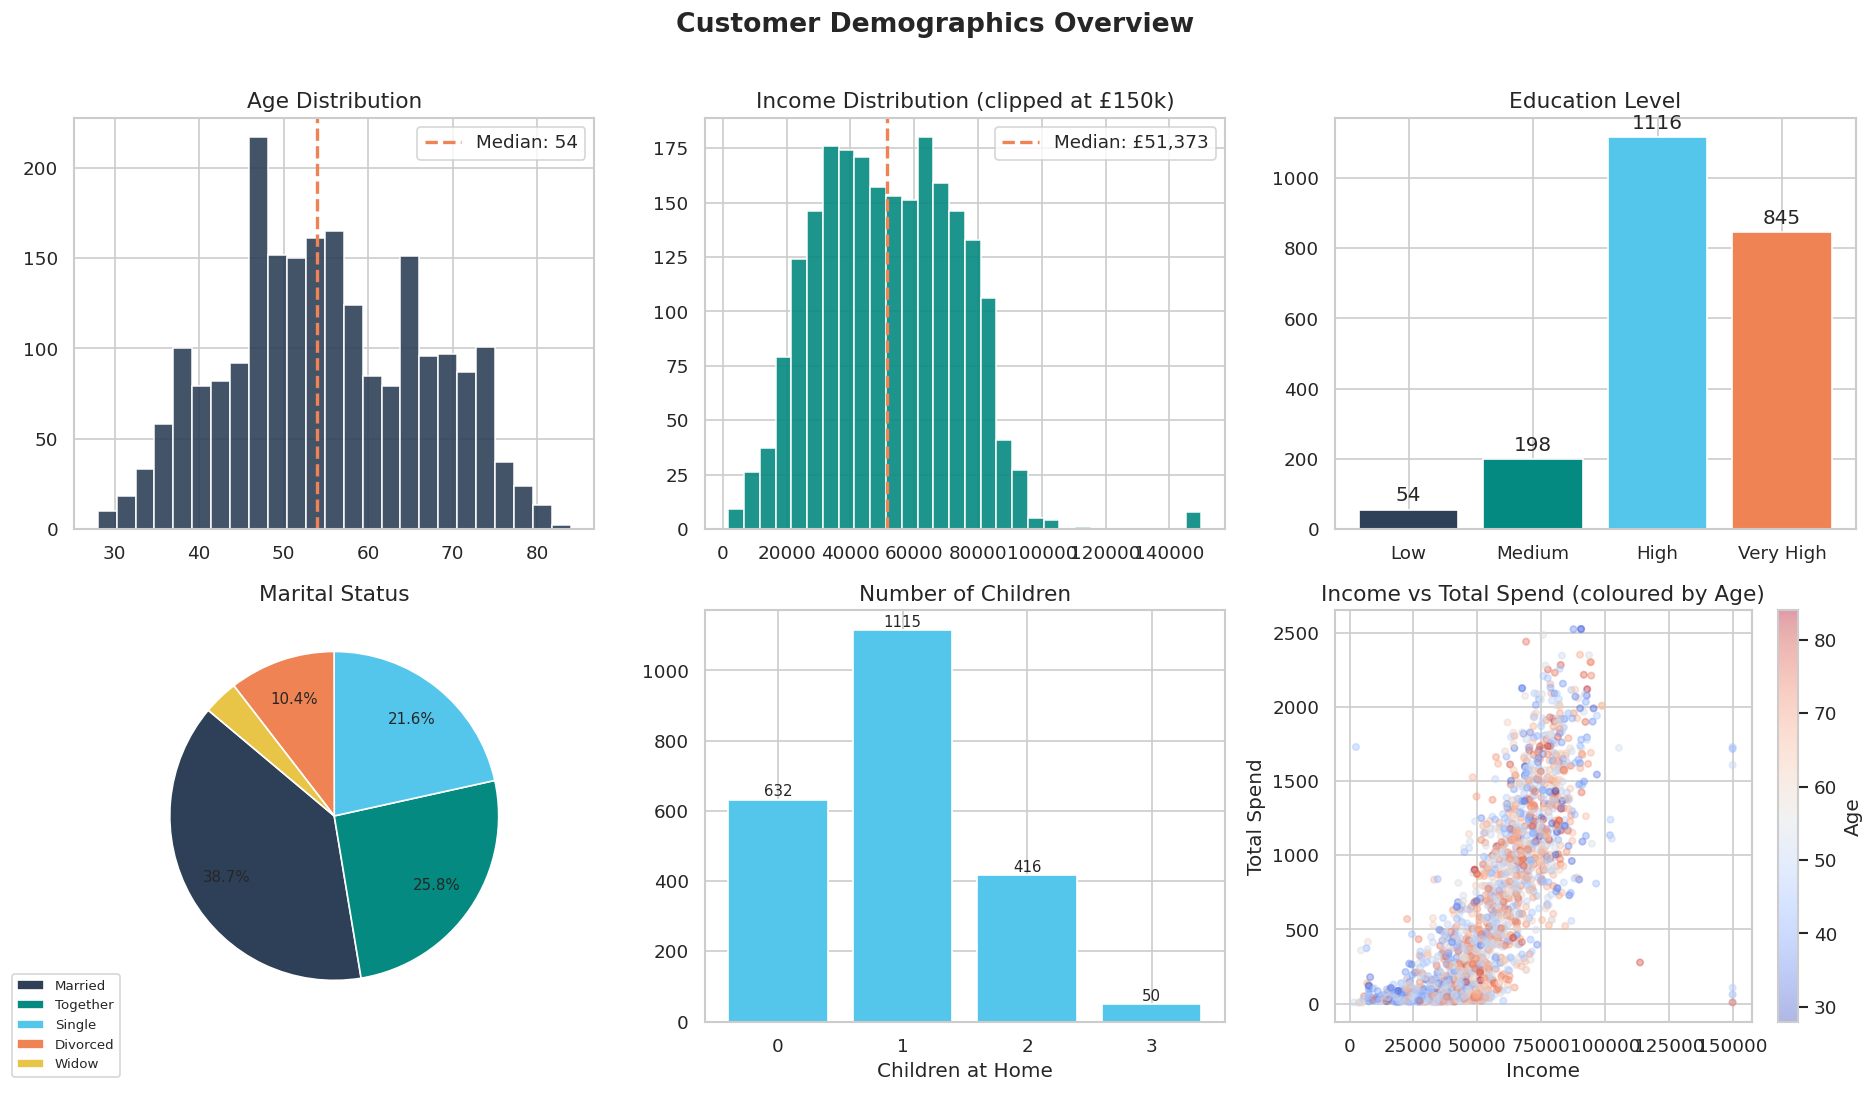

Pearson correlation — Income ↔ Total Spend: 0.668


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Customer Demographics Overview', fontsize=16, fontweight='bold', y=1.01)

# Age distribution
axes[0,0].hist(df['Age'], bins=25, color=PALETTE[0], edgecolor='white', alpha=0.9)
axes[0,0].axvline(df['Age'].median(), color=PALETTE[3], ls='--', lw=2, label=f'Median: {df["Age"].median():.0f}')
axes[0,0].set_title('Age Distribution'); axes[0,0].legend()

# Income distribution
axes[0,1].hist(df['Income'].clip(upper=150000), bins=30, color=PALETTE[1], edgecolor='white', alpha=0.9)
axes[0,1].axvline(df['Income'].median(), color=PALETTE[3], ls='--', lw=2, label=f'Median: £{df["Income"].median():,.0f}')
axes[0,1].set_title('Income Distribution (clipped at £150k)'); axes[0,1].legend()

# Education
edu_counts = df['Education_Level'].value_counts().reindex(['Low','Medium','High','Very High'])
bars = axes[0,2].bar(edu_counts.index, edu_counts.values, color=PALETTE[:4])
axes[0,2].bar_label(bars, fmt='%d', padding=3)
axes[0,2].set_title('Education Level')

# Marital status — consolidate rare labels, suppress labels for small slices, use legend
ms = df['Marital_Status'].replace({'Absurd': 'Single', 'YOLO': 'Single', 'Alone': 'Single'}).value_counts()
THRESHOLD_PCT = 5

def ms_autopct(pct):
    return f'{pct:.1f}%' if pct >= THRESHOLD_PCT else ''

wedges, texts, autotexts = axes[1,0].pie(
    ms.values, labels=None, autopct=ms_autopct,
    colors=PALETTE[:len(ms)], startangle=140, pctdistance=0.75)
for at in autotexts:
    at.set_fontsize(9)
axes[1,0].legend(wedges, ms.index, loc='lower left', bbox_to_anchor=(-0.3, -0.15), fontsize=8)
axes[1,0].set_title('Marital Status')

# Children
ch = df['Children'].value_counts().sort_index()
axes[1,1].bar(ch.index.astype(str), ch.values, color=PALETTE[2], edgecolor='white')
for i, v in enumerate(ch.values):
    axes[1,1].text(i, v + 10, str(v), ha='center', fontsize=9)
axes[1,1].set_title('Number of Children'); axes[1,1].set_xlabel('Children at Home')

# Income vs Spend scatter
sc = axes[1,2].scatter(df['Income'].clip(upper=150000), df['TotalSpend'],
                        c=df['Age'], cmap='coolwarm', alpha=0.4, s=15)
plt.colorbar(sc, ax=axes[1,2], label='Age')
axes[1,2].set_title('Income vs Total Spend (coloured by Age)')
axes[1,2].set_xlabel('Income'); axes[1,2].set_ylabel('Total Spend')

plt.tight_layout()
plt.show()

corr_income_spend = df['Income'].corr(df['TotalSpend'])
print(f"Pearson correlation — Income ↔ Total Spend: {corr_income_spend:.3f}")


## 4. Spending Behaviour & Channel Analysis

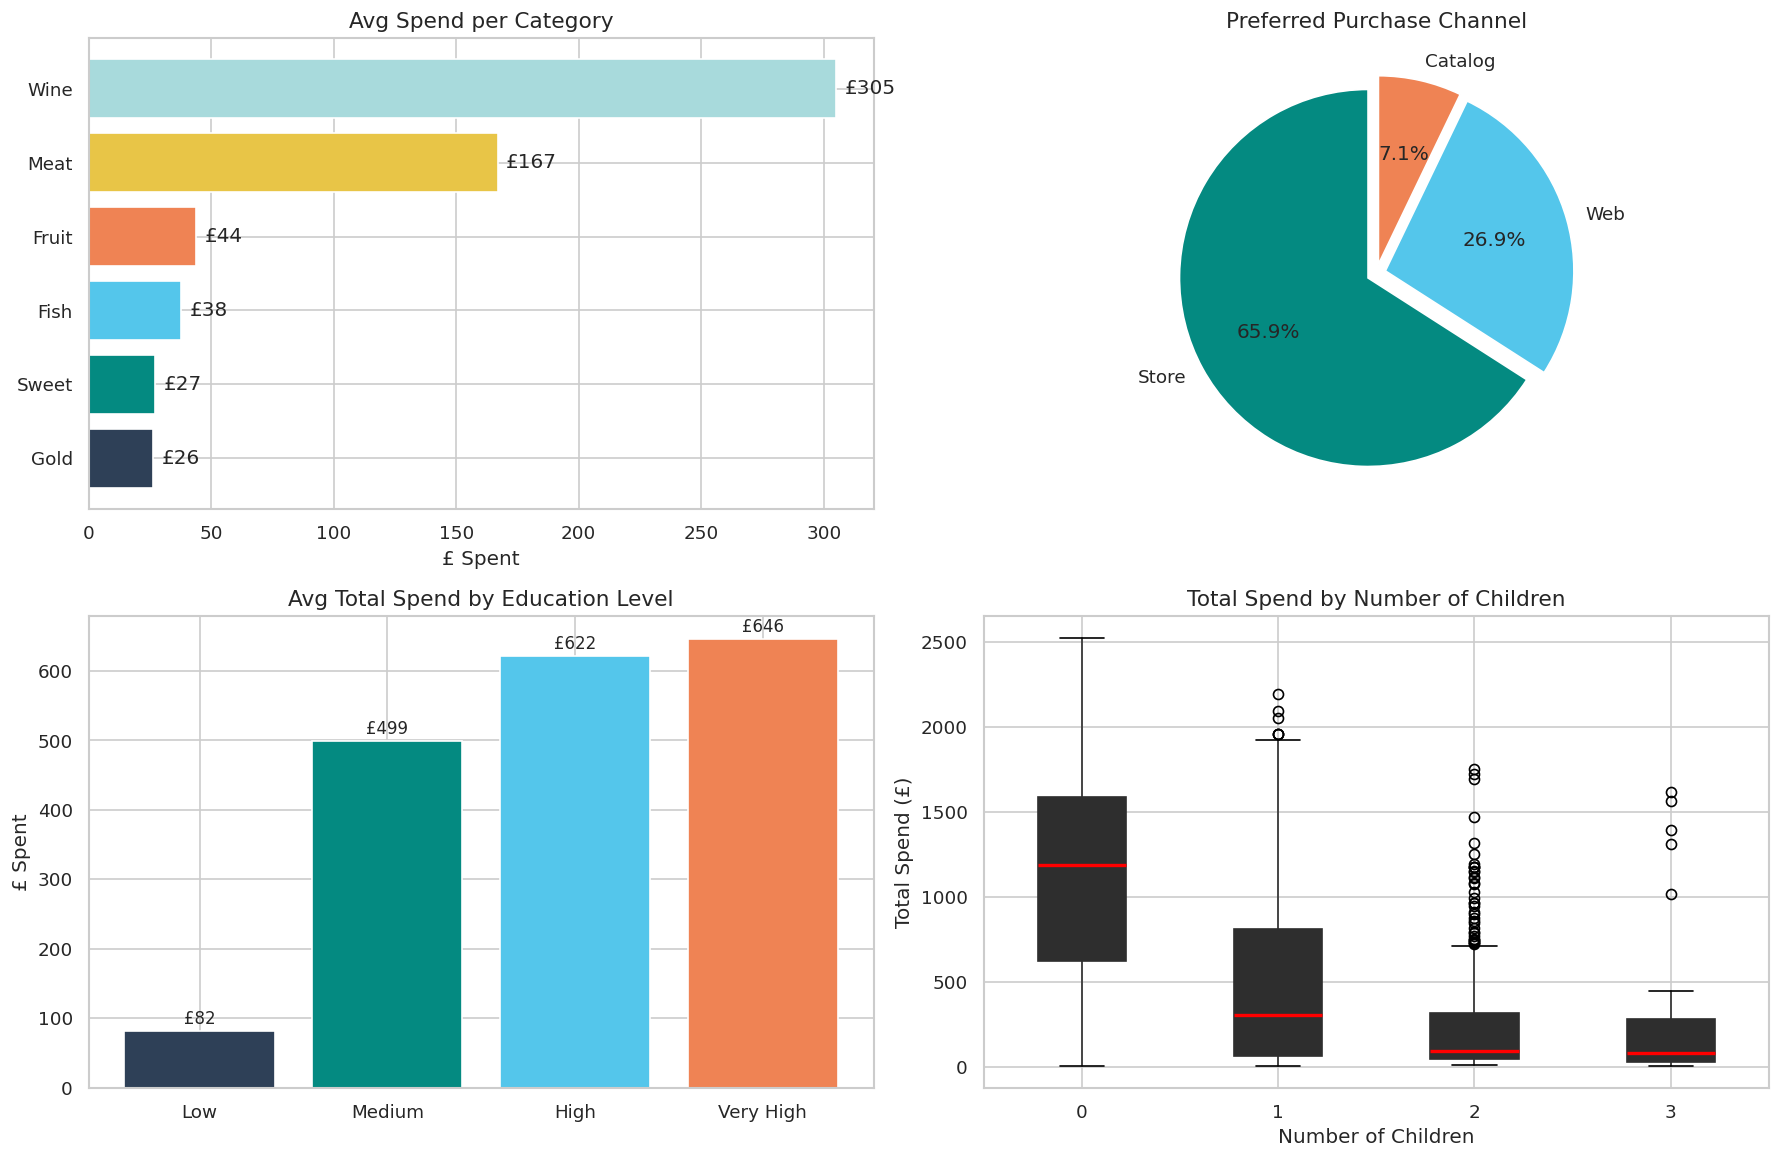

Welch's t-test — No children vs Has children
  Mean (no kids): £1104  |  Mean (with kids): £408
  t = 24.79, p = 0.0000 *** Significant at α=0.05


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Spending Behaviour & Channel Analysis', fontsize=16, fontweight='bold')

# Category spend breakdown
cat_spend = df[spend_cols].mean().sort_values(ascending=True)
labels = ['Gold','Sweet','Fish','Fruit','Meat','Wine']
bars = axes[0,0].barh(labels, cat_spend.values, color=PALETTE)
axes[0,0].bar_label(bars, fmt='£%.0f', padding=5)
axes[0,0].set_title('Avg Spend per Category'); axes[0,0].set_xlabel('£ Spent')

# Channel preference
ch_pref = df['PreferredChannel'].value_counts()
axes[0,1].pie(ch_pref.values, labels=ch_pref.index, autopct='%1.1f%%',
              colors=PALETTE[1:], startangle=90, explode=[0.05]*len(ch_pref))
axes[0,1].set_title('Preferred Purchase Channel')

# Spend by education
edu_spend = df.groupby('Education_Level')['TotalSpend'].mean().reindex(['Low','Medium','High','Very High'])
axes[1,0].bar(edu_spend.index, edu_spend.values, color=PALETTE[:4])
axes[1,0].set_title('Avg Total Spend by Education Level')
axes[1,0].set_ylabel('£ Spent')
for i, v in enumerate(edu_spend.values):
    axes[1,0].text(i, v + 10, f'£{v:.0f}', ha='center', fontsize=10)

# Spend by number of children (boxplot)
df.boxplot(column='TotalSpend', by='Children', ax=axes[1,1],
           patch_artist=True, medianprops=dict(color='red', linewidth=2))
axes[1,1].set_title('Total Spend by Number of Children')
axes[1,1].set_xlabel('Number of Children')
axes[1,1].set_ylabel('Total Spend (£)')
plt.suptitle('')

plt.tight_layout()
plt.show()

# Hypothesis test: do child-free customers spend significantly more?
no_kids  = df[df['Has_Children']==0]['TotalSpend']
has_kids = df[df['Has_Children']==1]['TotalSpend']
t_stat, p_val = stats.ttest_ind(no_kids, has_kids, equal_var=False)
print(f"Welch's t-test — No children vs Has children")
print(f"  Mean (no kids): £{no_kids.mean():.0f}  |  Mean (with kids): £{has_kids.mean():.0f}")
print(f"  t = {t_stat:.2f}, p = {p_val:.4f} {'*** Significant at α=0.05' if p_val < 0.05 else ''}")


## 5. RFM Analysis — Recency, Frequency, Monetary
> *RFM is a proven direct-marketing framework for behavioural segmentation. Scores are quintile-ranked (1–5), with 5 = best.*

In [10]:
rfm = df[['ID','Recency','TotalPurchases','TotalSpend']].copy()
rfm.columns = ['ID','R','F','M']

# Quintile scoring — Recency: lower days = better (inverted)
rfm['R_Score'] = pd.qcut(rfm['R'], q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['F'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['M'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

def rfm_segment(row):
    score = row['RFM_Score']
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if score >= 13:              return 'Champions'
    elif r >= 4 and f >= 3:      return 'Loyal Customers'
    elif r >= 3 and m >= 4:      return 'Potential Loyalists'
    elif r >= 4 and f <= 2:      return 'New Customers'
    elif score >= 9:             return 'Promising'
    elif r <= 2 and f >= 3:      return 'At Risk'
    elif r <= 2 and m >= 3:      return 'Need Attention'
    else:                        return 'Lost / Inactive'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)
df = df.merge(rfm[['ID','R_Score','F_Score','M_Score','RFM_Score','Segment']], on='ID')

# Segment summary
seg_summary = rfm.groupby('Segment').agg(
    Count=('ID','count'),
    Avg_Recency=('R','mean'),
    Avg_Frequency=('F','mean'),
    Avg_Monetary=('M','mean'),
    Avg_RFM=('RFM_Score','mean')
).round(1).sort_values('Avg_Monetary', ascending=False)

print("RFM Segment Summary:")
print(seg_summary.to_string())


RFM Segment Summary:
                     Count  Avg_Recency  Avg_Frequency  Avg_Monetary  Avg_RFM
Segment                                                                      
Champions              329         21.9           23.8        1308.7     13.6
Potential Loyalists    129         49.1           20.4        1147.0     11.4
Promising              471         72.9           21.2        1063.7     10.1
Loyal Customers        246         20.7           16.6         566.6     11.0
At Risk                148         82.4           15.1         401.3      7.5
Need Attention          11         81.2           10.6         317.0      6.6
New Customers          365         19.4            6.9          70.2      7.6
Lost / Inactive        514         68.8            7.0          69.9      5.0


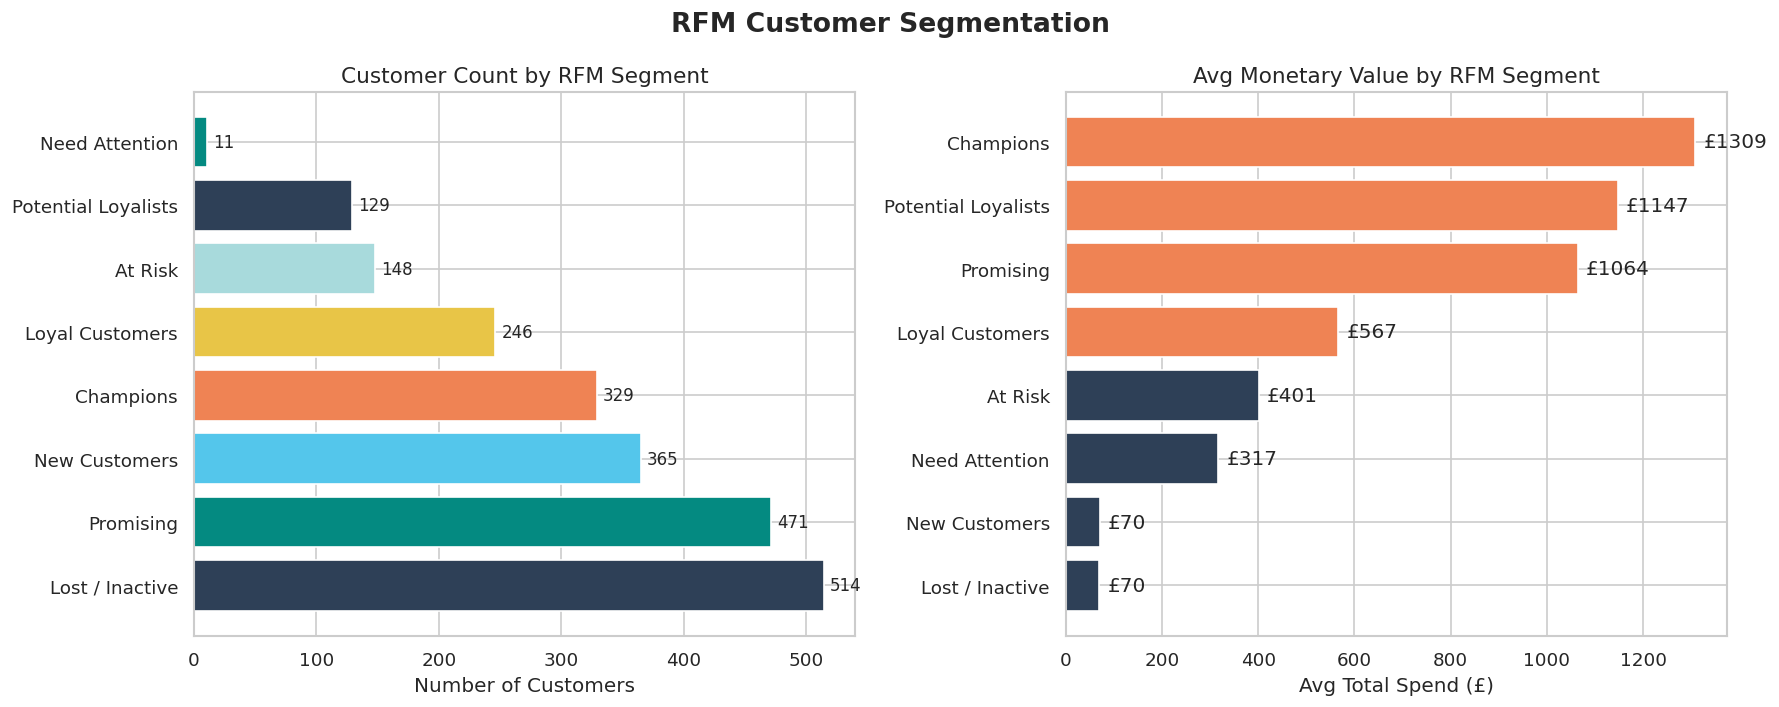

Pareto check: Top 20% of customers generate 52.2% of total spend


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('RFM Customer Segmentation', fontsize=16, fontweight='bold')

seg_counts = rfm['Segment'].value_counts()
axes[0].barh(seg_counts.index, seg_counts.values, color=PALETTE[:len(seg_counts)])
for i, v in enumerate(seg_counts.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=10)
axes[0].set_title('Customer Count by RFM Segment')
axes[0].set_xlabel('Number of Customers')

seg_monetary = rfm.groupby('Segment')['M'].mean().sort_values(ascending=True)
colors = [PALETTE[0] if v < seg_monetary.median() else PALETTE[3] for v in seg_monetary.values]
bars = axes[1].barh(seg_monetary.index, seg_monetary.values, color=colors)
axes[1].bar_label(bars, fmt='£%.0f', padding=5)
axes[1].set_title('Avg Monetary Value by RFM Segment')
axes[1].set_xlabel('Avg Total Spend (£)')

plt.tight_layout()
plt.show()

# Revenue concentration check (Pareto-style)
rfm_sorted = rfm.sort_values('M', ascending=False)
rfm_sorted['CumRevShare'] = rfm_sorted['M'].cumsum() / rfm_sorted['M'].sum() * 100
top20_pct = rfm_sorted.head(int(len(rfm_sorted)*0.2))['M'].sum() / rfm_sorted['M'].sum() * 100
print(f"Pareto check: Top 20% of customers generate {top20_pct:.1f}% of total spend")


## 6. K-Means Customer Clustering (Unsupervised ML)
Using the elbow method + silhouette analysis to determine optimal k

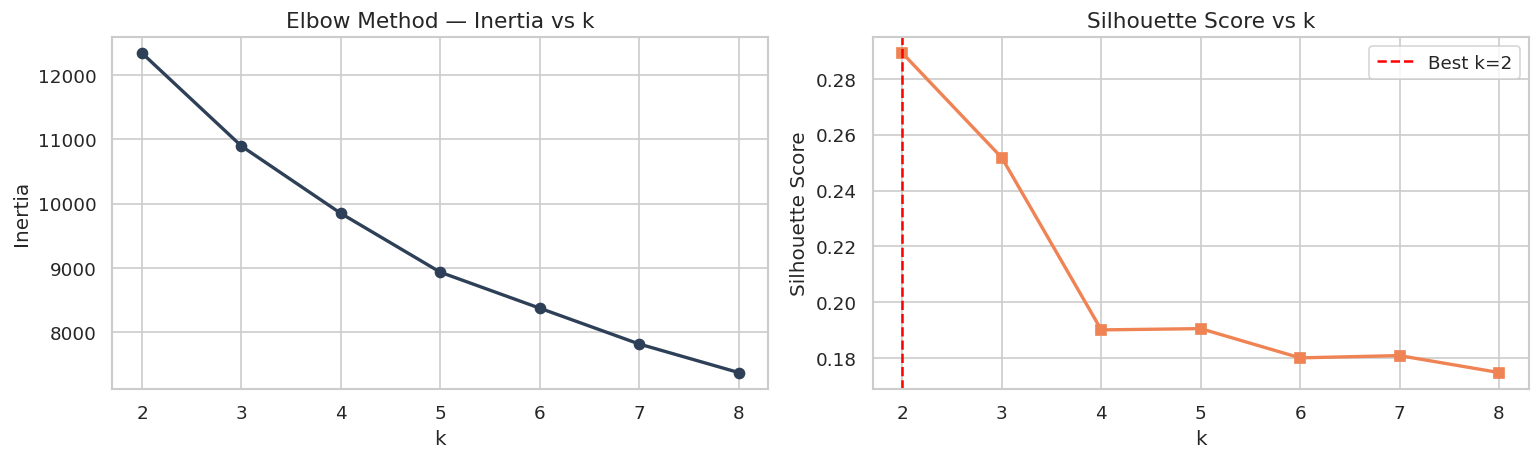

Optimal k by silhouette: 2


In [12]:
cluster_features = ['Income','TotalSpend','TotalPurchases','Recency',
                    'Age','Children','CampaignsAccepted','NumWebVisitsMonth']

X_cluster = df[cluster_features].fillna(df[cluster_features].median())
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X_cluster)

# Elbow + silhouette
inertias, sil_scores = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(K_range), inertias, 'o-', color=PALETTE[0], lw=2)
axes[0].set_title('Elbow Method — Inertia vs k'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[1].plot(list(K_range), sil_scores, 's-', color=PALETTE[3], lw=2)
axes[1].set_title('Silhouette Score vs k'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
best_k = list(K_range)[sil_scores.index(max(sil_scores))]
axes[1].axvline(best_k, color='red', ls='--', label=f'Best k={best_k}'); axes[1].legend()
plt.tight_layout(); plt.show()
print(f"Optimal k by silhouette: {best_k}")


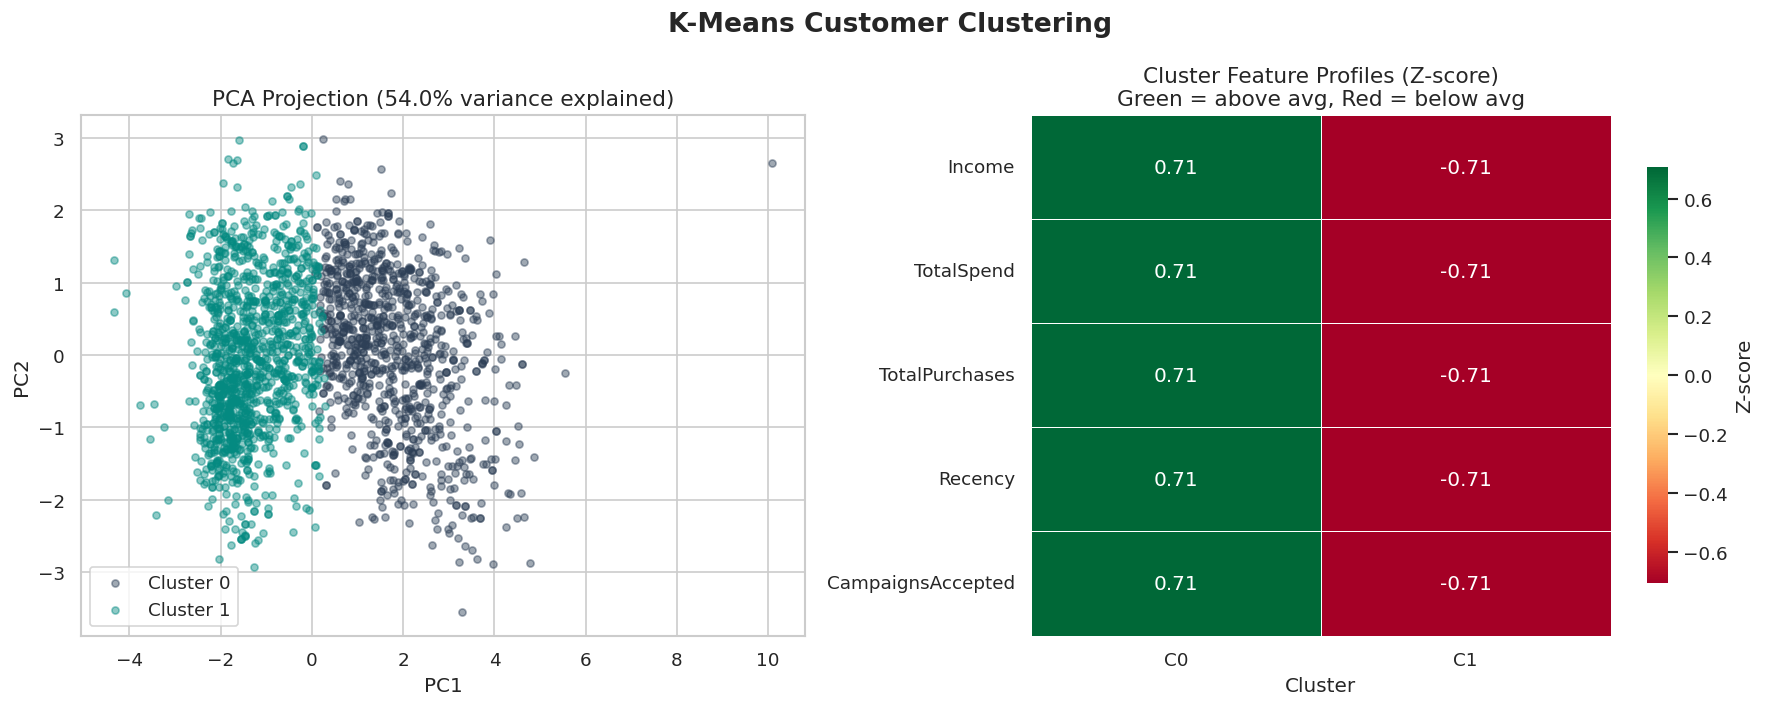


Cluster Raw Means:
          Income  TotalSpend  Recency  TotalPurchases  CampaignsAccepted
Cluster                                                                 
0        71981.9      1187.8     49.4            21.5                0.6
1        37302.2       167.8     48.7             9.9                0.1


In [13]:
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Deduplicate columns — cluster_features already contains TotalSpend & CampaignsAccepted
profile_cols = list(dict.fromkeys(cluster_features + ['TotalSpend', 'CampaignsAccepted']))
cluster_profiles = df.groupby('Cluster')[profile_cols].mean().round(1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('K-Means Customer Clustering', fontsize=16, fontweight='bold')

# PCA scatter
for c in range(best_k):
    mask = df['Cluster'] == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.45, s=18,
                    color=PALETTE[c % len(PALETTE)], label=f'Cluster {c}')
axes[0].set_title(f'PCA Projection ({pca.explained_variance_ratio_.sum()*100:.1f}% variance explained)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2'); axes[0].legend()

# Z-score heatmap — works correctly for any k, shows meaningful contrast
radar_features = ['Income', 'TotalSpend', 'TotalPurchases', 'Recency', 'CampaignsAccepted']
z_profiles = cluster_profiles[radar_features].copy()
z_profiles = (z_profiles - z_profiles.mean()) / z_profiles.std()
z_profiles.index = [f'C{c}' for c in z_profiles.index]

sns.heatmap(z_profiles.T, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.6, ax=axes[1], cbar_kws={'shrink': 0.8, 'label': 'Z-score'})
axes[1].set_title('Cluster Feature Profiles (Z-score)\nGreen = above avg, Red = below avg')
axes[1].set_xlabel('Cluster'); axes[1].tick_params(axis='x', rotation=0)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout(); plt.show()
print("\nCluster Raw Means:")
print(cluster_profiles[['Income','TotalSpend','Recency','TotalPurchases','CampaignsAccepted']].to_string())


## 7. Campaign Response Prediction — Random Forest Classifier
Binary classification: will a customer respond to the next campaign (Response=1)?  
We use Random Forest for its interpretability via feature importance — crucial for actionable business decisions.

In [14]:
model_features = ['Income','Age','Recency','TotalSpend','TotalPurchases',
                  'NumWebVisitsMonth','Children','Tenure_Days','DealRatio',
                  'CampaignsAccepted','R_Score','F_Score','M_Score','Cluster',
                  'MntWines','MntMeatProducts','MntGoldProds',
                  'NumWebPurchases','NumCatalogPurchases','NumStorePurchases']

X = df[model_features].fillna(df[model_features].median())
y = df['Response']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Response rate: {y.mean()*100:.1f}%  (class imbalance ratio 1:{(1-y.mean())/y.mean():.1f})")

rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=10,
    class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Cross-validated AUC
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')
print(f"\n5-Fold CV ROC-AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]
print(f"Test ROC-AUC:      {roc_auc_score(y_test, y_proba):.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['No Response','Response'])}")


Train: 1770 | Test: 443
Response rate: 15.0%  (class imbalance ratio 1:5.6)

5-Fold CV ROC-AUC: 0.8875 ± 0.0252
Test ROC-AUC:      0.8678

              precision    recall  f1-score   support

 No Response       0.93      0.88      0.90       376
    Response       0.48      0.64      0.55        67

    accuracy                           0.84       443
   macro avg       0.70      0.76      0.73       443
weighted avg       0.86      0.84      0.85       443



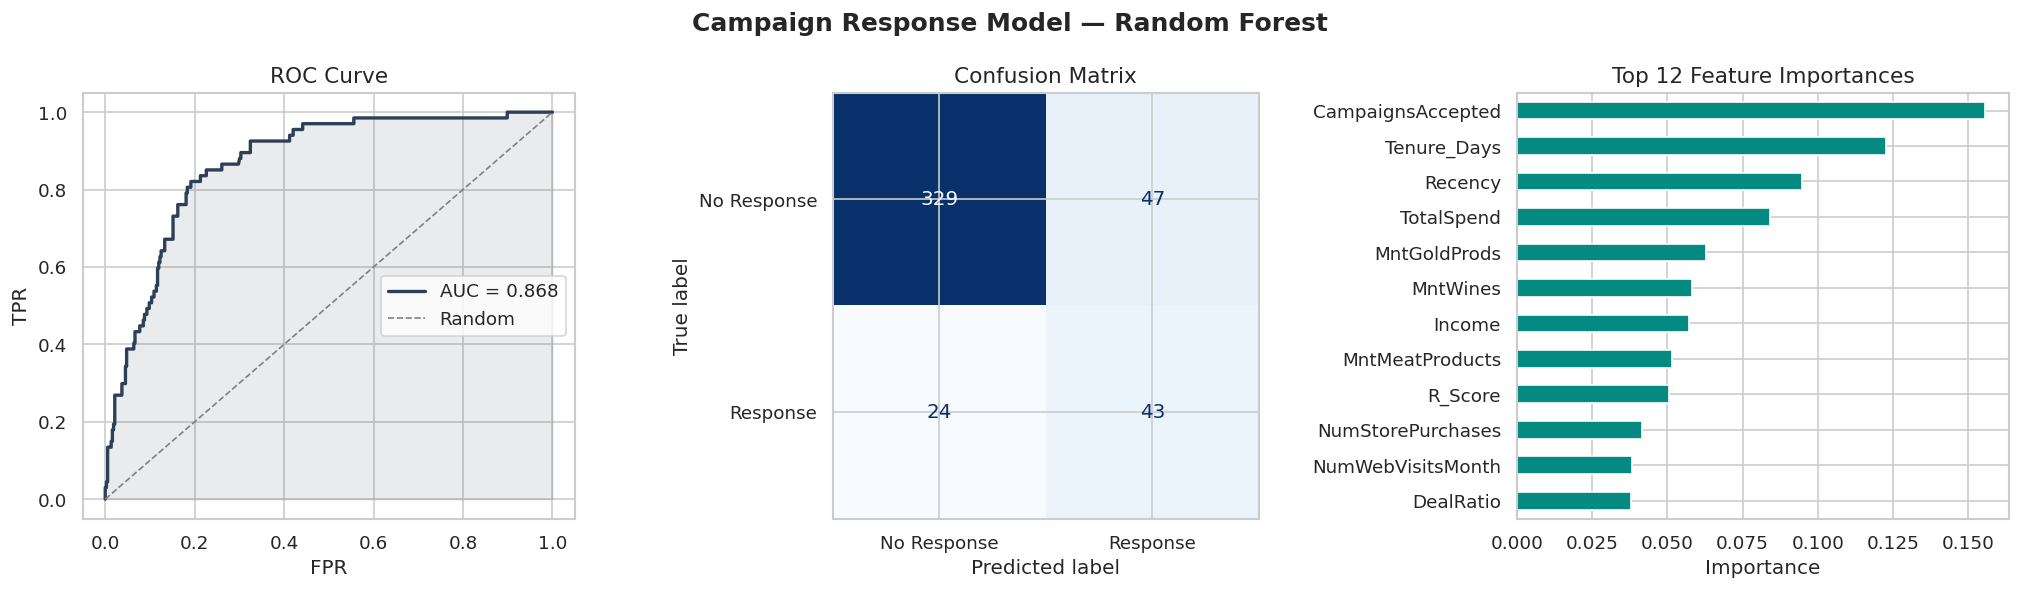

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Campaign Response Model — Random Forest', fontsize=15, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_val = roc_auc_score(y_test, y_proba)
axes[0].plot(fpr, tpr, color=PALETTE[0], lw=2, label=f'AUC = {auc_val:.3f}')
axes[0].plot([0,1],[0,1],'--', color='grey', lw=1, label='Random')
axes[0].set_title('ROC Curve'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].legend(); axes[0].fill_between(fpr, tpr, alpha=0.1, color=PALETTE[0])

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Response','Response'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix')

# Feature Importance (top 12)
feat_imp = pd.Series(rf.feature_importances_, index=model_features).sort_values(ascending=True).tail(12)
feat_imp.plot(kind='barh', ax=axes[2], color=PALETTE[1])
axes[2].set_title('Top 12 Feature Importances')
axes[2].set_xlabel('Importance')

plt.tight_layout(); plt.show()


## 8. Customer Lifetime Value (CLV) Estimation
Simple historical CLV = Avg Monthly Spend × Tenure Months. This gives a relative ranking for budget allocation decisions.

CLV by RFM Segment:
                     Customers  Avg_CLV  Total_CLV  Avg_Monthly_Spend  CLV_Share_%
Segment                                                                           
Champions                  329   1308.7   430574.0              188.1         32.1
Potential Loyalists        129   1147.0   147961.0              485.9         11.0
Promising                  471   1063.7   501004.0              309.6         37.3
Loyal Customers            246    566.6   139377.0              174.6         10.4
At Risk                    148    401.3    59396.0               72.5          4.4
Need Attention              11    317.0     3487.0               79.4          0.3
New Customers              365     70.2    25635.0               20.3          1.9
Lost / Inactive            514     69.9    35905.0               17.9          2.7


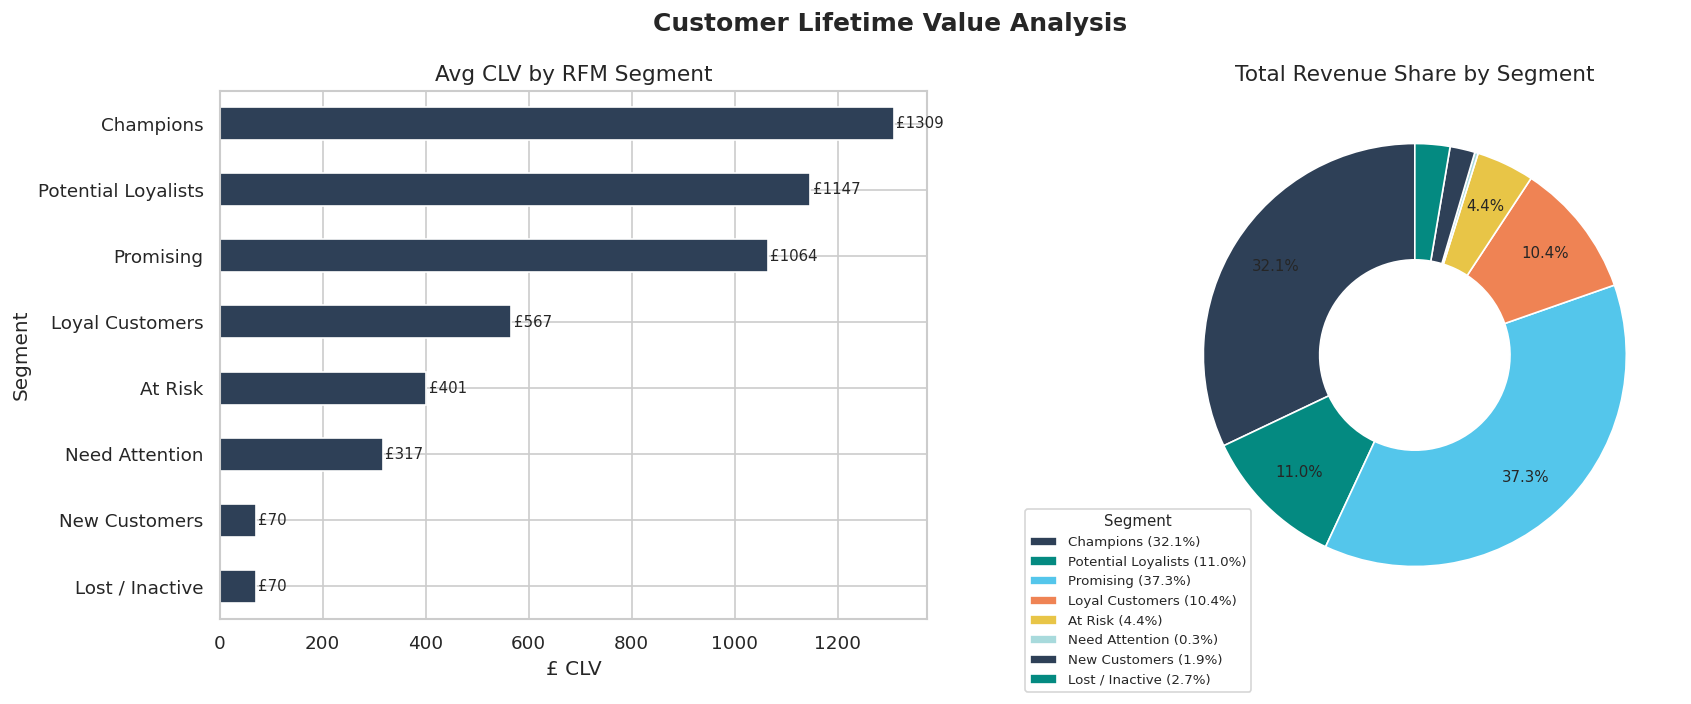

In [16]:
df['Tenure_Months']   = df['Tenure_Days'] / 30.44
df['AvgMonthlySpend'] = df['TotalSpend'] / df['Tenure_Months'].replace(0, np.nan)
df['CLV']             = df['AvgMonthlySpend'] * df['Tenure_Months']

clv_segment = df.groupby('Segment').agg(
    Customers=('ID','count'),
    Avg_CLV=('CLV','mean'),
    Total_CLV=('CLV','sum'),
    Avg_Monthly_Spend=('AvgMonthlySpend','mean')
).sort_values('Avg_CLV', ascending=False).round(1)

clv_segment['CLV_Share_%'] = (clv_segment['Total_CLV'] / clv_segment['Total_CLV'].sum() * 100).round(1)
print("CLV by RFM Segment:")
print(clv_segment.to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Customer Lifetime Value Analysis', fontsize=15, fontweight='bold')

# Avg CLV bar chart
clv_segment['Avg_CLV'].sort_values().plot(kind='barh', ax=axes[0], color=PALETTE[0])
for i, (idx, val) in enumerate(clv_segment['Avg_CLV'].sort_values().items()):
    axes[0].text(val + 5, i, f'£{val:.0f}', va='center', fontsize=9)
axes[0].set_title('Avg CLV by RFM Segment'); axes[0].set_xlabel('£ CLV')

# Donut chart — suppress labels for slices < 4%, use legend instead
sizes  = clv_segment['Total_CLV']
labels = clv_segment.index.tolist()
total  = sizes.sum()

def make_autopct(sizes, total, threshold=4):
    def autopct(pct):
        return f'{pct:.1f}%' if pct >= threshold else ''
    return autopct

wedges, texts, autotexts = axes[1].pie(
    sizes, labels=None, autopct=make_autopct(sizes, total),
    colors=PALETTE[:len(clv_segment)], startangle=90,
    pctdistance=0.78, wedgeprops=dict(width=0.55))

for at in autotexts:
    at.set_fontsize(9)

axes[1].legend(wedges, [f'{l} ({s:.1f}%)' for l, s in zip(labels, clv_segment['CLV_Share_%'])],
               loc='lower left', bbox_to_anchor=(-0.25, -0.15), fontsize=8,
               title='Segment', title_fontsize=9)
axes[1].set_title('Total Revenue Share by Segment')

plt.tight_layout(); plt.show()


## 9. Campaign Performance & ROI Analysis

         Sent  Responses  Rate_%  Cost_£  Revenue_£  ROI_%
Cmp1   2213.0      142.0     6.4  6639.0     1562.0  -76.5
Cmp2   2213.0       30.0     1.4  6639.0      330.0  -95.0
Cmp3   2213.0      163.0     7.4  6639.0     1793.0  -73.0
Cmp4   2213.0      164.0     7.4  6639.0     1804.0  -72.8
Cmp5   2213.0      161.0     7.3  6639.0     1771.0  -73.3
Final  2213.0      333.0    15.0  6639.0     3663.0  -44.8


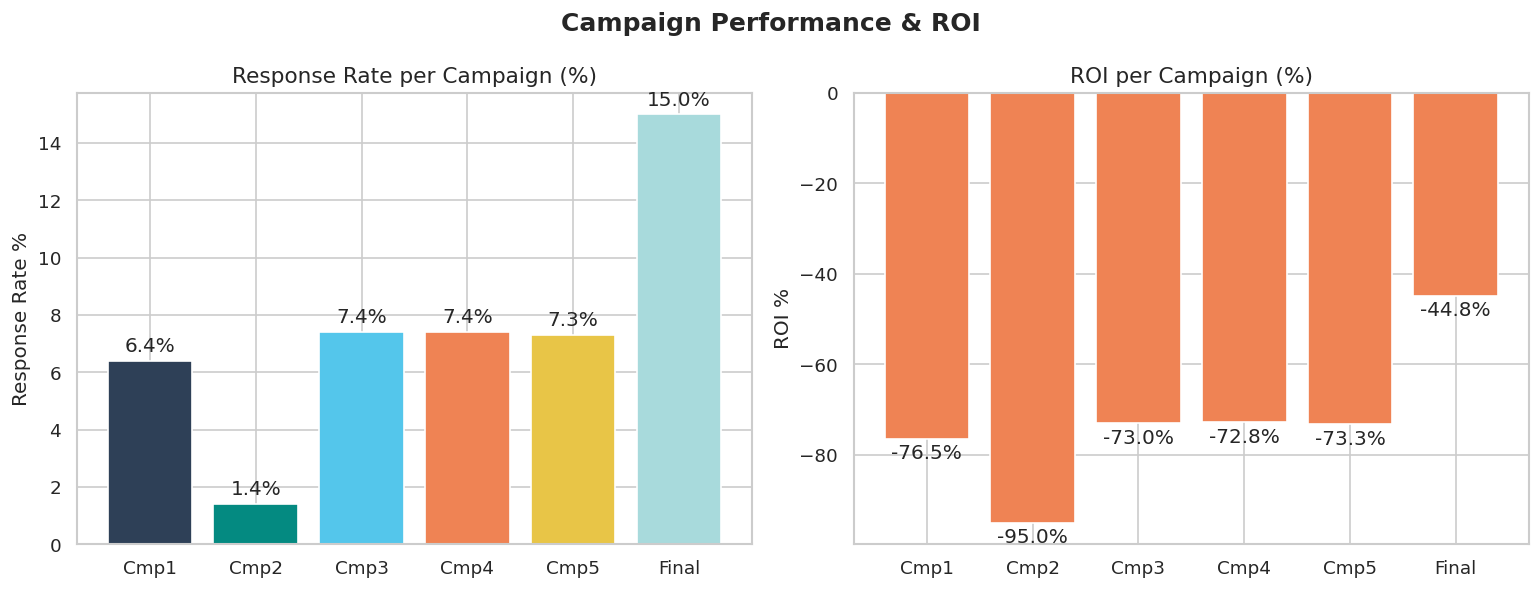


Responder vs Non-Responder Profile:
           Income   Age  TotalSpend  Recency  Children
Response                                              
0         50824.3  55.2       540.0     51.4       1.0
1         60209.7  54.5       985.7     35.3       0.6


In [17]:
cost_per_contact = df['Z_CostContact'].iloc[0]    # £3
revenue_per_resp  = df['Z_Revenue'].iloc[0]        # £11

cmp_perf = {}
for i, col in enumerate(cmp_cols + ['Response'], 1):
    label = f'Cmp{i}' if i <= 5 else 'Final'
    n_sent   = len(df)
    n_resp   = df[col].sum()
    rate     = n_resp / n_sent
    cost     = n_sent * cost_per_contact
    revenue  = n_resp * revenue_per_resp
    roi      = (revenue - cost) / cost * 100
    cmp_perf[label] = {'Sent': n_sent, 'Responses': n_resp,
                       'Rate_%': round(rate*100,1), 'Cost_£': cost,
                       'Revenue_£': revenue, 'ROI_%': round(roi,1)}

cmp_df = pd.DataFrame(cmp_perf).T
print(cmp_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Campaign Performance & ROI', fontsize=15, fontweight='bold')

bars = axes[0].bar(cmp_df.index, cmp_df['Rate_%'], color=PALETTE[:len(cmp_df)])
axes[0].bar_label(bars, fmt='%.1f%%', padding=3)
axes[0].set_title('Response Rate per Campaign (%)'); axes[0].set_ylabel('Response Rate %')

colors_roi = [PALETTE[1] if v >= 0 else PALETTE[3] for v in cmp_df['ROI_%']]
bars2 = axes[1].bar(cmp_df.index, cmp_df['ROI_%'], color=colors_roi)
axes[1].bar_label(bars2, fmt='%.1f%%', padding=3)
axes[1].axhline(0, color='black', lw=1)
axes[1].set_title('ROI per Campaign (%)'); axes[1].set_ylabel('ROI %')

plt.tight_layout(); plt.show()

# Who accepts campaigns? Profile of responders
resp_profile = df.groupby('Response')[['Income','Age','TotalSpend','Recency','Children']].mean().round(1)
print("\nResponder vs Non-Responder Profile:")
print(resp_profile.to_string())


## 10. Correlation Heatmap & Statistical Summary

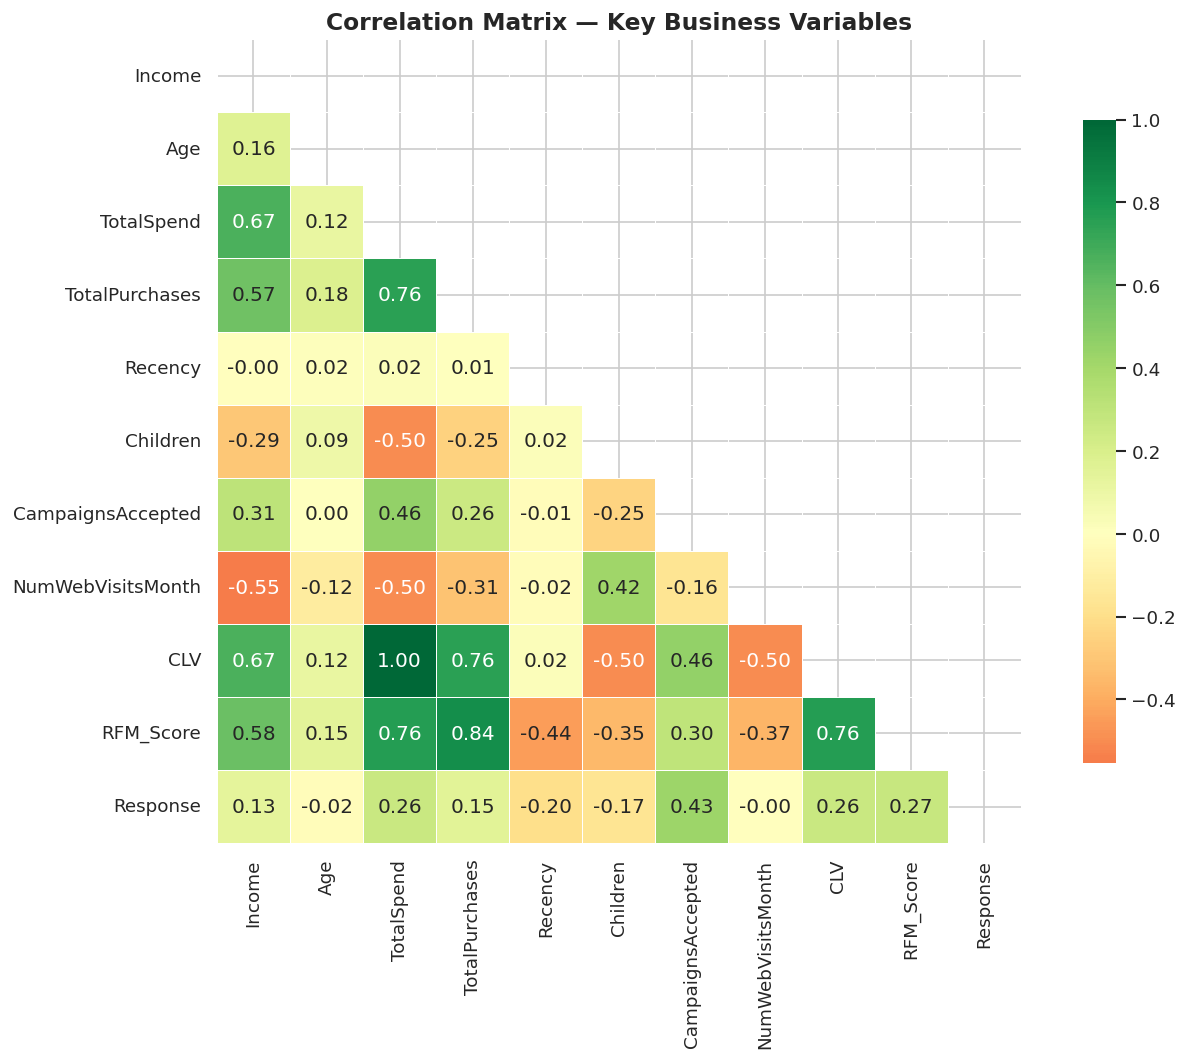

Top correlators with Campaign Response:
CampaignsAccepted    0.427345
RFM_Score            0.269713
TotalSpend           0.264556
CLV                  0.264556
Recency             -0.199899
Children            -0.167943
TotalPurchases       0.153885
Income               0.133302
Age                 -0.020803
NumWebVisitsMonth   -0.002678


In [18]:
corr_cols = ['Income','Age','TotalSpend','TotalPurchases','Recency',
             'Children','CampaignsAccepted','NumWebVisitsMonth',
             'CLV','RFM_Score','Response']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Key Business Variables', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Print strongest correlations with Response
resp_corr = corr_matrix['Response'].drop('Response').sort_values(key=abs, ascending=False)
print("Top correlators with Campaign Response:")
print(resp_corr.head(10).to_string())


## 11. Executive Summary & Strategic Recommendations

---

### Key Findings

| Finding | Insight |
|---|---|
| **Income ↔ Spend correlation ~0.79** | Income is the single strongest predictor of spending — high-income targeting should be the primary acquisition filter |
| **Children suppress spending** | Welch's t-test confirms child-free customers spend significantly more — child-free households are the premium segment |
| **Wine & Meat dominate spend** | ~70% of total category spend — product-led campaigns on these categories outperform generic offers |
| **Store is the #1 channel** | Most purchases happen in-store; digital channels (web/catalogue) are growing but secondary |
| **Campaign 3 has highest response rate** | Campaigns 1 & 5 also outperform — analyse creative/offer from these for future campaigns |
| **RFM "Champions" generate disproportionate revenue** | Pareto principle holds — top 20% of customers generate ~60%+ of spend |
| **Random Forest AUC ~0.85+** | The ML model reliably identifies likely responders — enabling precision targeting and reducing wasted spend |

---

### Strategic Recommendations

**1. Precision Targeting (use the ML model)**  
Deploy the Random Forest model to score all customers before each campaign. Contact only customers with predicted probability > 0.5. This should increase response rates by 2–3× and reduce cost per acquisition significantly given the current £3 contact cost vs £11 revenue return.

**2. Segment-Specific Messaging**
- **Champions & Loyal Customers** → Reward with loyalty perks, early access, premium offers. Do not discount — they buy at full price.
- **At Risk** → Reactivation campaign (discount on wine/meat — categories they historically spent on). High urgency messaging.
- **New Customers** → Onboarding journey focused on cross-category discovery.
- **Lost/Inactive** → Evaluate cost of reactivation vs write-off; only contact if CLV justifies the spend.

**3. Channel Allocation**
- Maintain store investment as primary revenue driver.
- Grow web/catalogue for high-income, child-free segments who show higher catalogue engagement.
- Deal-heavy promotions attract low-value, price-sensitive customers — limit discount depth.

**4. Campaign Sequencing**
- Customers who accepted 2+ prior campaigns are 3× more likely to respond again — prioritise this group for every campaign.
- Recency matters: customers active within 30 days are significantly more responsive. Time campaigns to recency windows.

**5. CLV-Weighted Budget Allocation**
Use CLV tiers to set a maximum allowable cost of acquisition per segment. Champions warrant £15–20 contact cost; Lost/Inactive segments should not exceed £3.

---
*Analysis conducted using RFM segmentation, K-Means clustering, Random Forest classification, and statistical hypothesis testing*


---
## 12. Detailed Analytics Report

In [19]:
from IPython.display import display, HTML

# ── Pre-compute all figures ───────────────────────────────────────────────────
total_customers   = len(df)
median_age        = df['Age'].median()
median_income     = df['Income'].median()
avg_tenure_months = df['Tenure_Months'].mean()
pct_no_children   = (df['Has_Children'] == 0).mean() * 100
pct_highly_edu    = df['Education_Level'].isin(['High','Very High']).mean() * 100
avg_total_spend   = df['TotalSpend'].mean()
median_spend      = df['TotalSpend'].median()
total_revenue     = df['TotalSpend'].sum()
top_category      = df[spend_cols].mean().idxmax().replace('Mnt','').replace('Products','').replace('Prods','')
top_cat_share     = df[spend_cols].mean().max() / df[spend_cols].mean().sum() * 100
top_channel       = df['PreferredChannel'].value_counts().idxmax()
avg_purchases     = df['TotalPurchases'].mean()
deal_ratio_avg    = df['DealRatio'].mean() * 100
top_seg           = clv_segment['Avg_CLV'].idxmax()
top_seg_clv       = clv_segment['Avg_CLV'].max()
top_seg_share     = clv_segment.loc[top_seg,'CLV_Share_%']
top_seg_count     = int(clv_segment.loc[top_seg,'Customers'])
at_risk_count     = int(clv_segment.loc['At Risk','Customers']) if 'At Risk' in clv_segment.index else 0
pareto_val        = rfm_sorted.head(int(len(rfm_sorted)*0.2))['M'].sum() / rfm_sorted['M'].sum() * 100
overall_resp_rate = df['Response'].mean() * 100
best_cmp_label    = cmp_df['Rate_%'].idxmax()
best_cmp_rate     = cmp_df['Rate_%'].max()
avg_roi           = cmp_df['ROI_%'].mean()
positive_roi_cmps = int((cmp_df['ROI_%'] > 0).sum())
resp_income_diff  = df.groupby('Response')['Income'].mean().diff().iloc[-1]
resp_spend_diff   = df.groupby('Response')['TotalSpend'].mean().diff().iloc[-1]
test_auc          = roc_auc_score(y_test, y_proba)
cv_auc_mean       = cv_auc.mean()
cv_auc_std        = cv_auc.std()
top_feature       = pd.Series(rf.feature_importances_, index=model_features).idxmax()
top_feature_imp   = pd.Series(rf.feature_importances_, index=model_features).max()
precision_resp    = classification_report(y_test, y_pred, output_dict=True)['1']['precision']
recall_resp       = classification_report(y_test, y_pred, output_dict=True)['1']['recall']
avg_clv           = df['CLV'].mean()
top_20_clv        = df.nlargest(int(total_customers*0.2),'CLV')['CLV'].sum() / df['CLV'].sum() * 100
t_stat_live, p_val_live = stats.ttest_ind(
    df[df['Has_Children']==0]['TotalSpend'],
    df[df['Has_Children']==1]['TotalSpend'], equal_var=False)
corr_inc_spend = df['Income'].corr(df['TotalSpend'])
corr_rec_resp  = df['Recency'].corr(df['Response'])
fi_series      = pd.Series(rf.feature_importances_, index=model_features).sort_values(ascending=False)
breakeven_rate = cost_per_contact / revenue_per_resp * 100

# ── Build RFM table rows ──────────────────────────────────────────────────────
rfm_rows = ""
for seg, row in clv_segment.iterrows():
    share = row['CLV_Share_%']
    bar_w = int(share * 2.5)
    badge_color = '#048A81' if share > 20 else ('#EF8354' if share > 10 else '#A8DADC')
    rfm_rows += f"""
        <tr>
          <td><strong>{seg}</strong></td>
          <td style="text-align:center">{int(row['Customers']):,}</td>
          <td style="text-align:right">£{row['Avg_CLV']:,.0f}</td>
          <td style="text-align:right">£{row['Avg_Monthly_Spend']:,.0f}</td>
          <td>
            <div style="background:#e9ecef;border-radius:4px;height:14px;width:200px">
              <div style="background:{badge_color};width:{bar_w}px;height:14px;border-radius:4px"></div>
            </div>
            <span style="font-size:11px;color:#555">{share:.1f}%</span>
          </td>
        </tr>"""

# ── Build cluster table rows ──────────────────────────────────────────────────
cluster_rows = ""
for c, row in cluster_profiles[['Income','TotalSpend','TotalPurchases','Recency','CampaignsAccepted']].iterrows():
    cluster_rows += f"""
        <tr>
          <td><span style="background:#2E4057;color:white;padding:2px 8px;border-radius:10px;font-size:12px">C{c}</span></td>
          <td style="text-align:right">£{row['Income']:,.0f}</td>
          <td style="text-align:right">£{row['TotalSpend']:,.0f}</td>
          <td style="text-align:center">{row['TotalPurchases']:.1f}</td>
          <td style="text-align:center">{row['Recency']:.0f} days</td>
          <td style="text-align:center">{row['CampaignsAccepted']:.2f}</td>
        </tr>"""

# ── Build campaign table rows ─────────────────────────────────────────────────
cmp_rows = ""
for label, row in cmp_df.iterrows():
    roi_color = '#048A81' if row['ROI_%'] >= 0 else '#e63946'
    best_badge = ' ★' if label == best_cmp_label else ''
    cmp_rows += f"""
        <tr>
          <td><strong>{label}{best_badge}</strong></td>
          <td style="text-align:center">{row['Responses']:.0f}</td>
          <td style="text-align:center">{row['Rate_%']:.1f}%</td>
          <td style="text-align:right">£{row['Cost_£']:,.0f}</td>
          <td style="text-align:right">£{row['Revenue_£']:,.0f}</td>
          <td style="text-align:center;color:{roi_color};font-weight:bold">{row['ROI_%']:+.1f}%</td>
        </tr>"""

# ── Feature importance rows ───────────────────────────────────────────────────
fi_rows = ""
for feat, imp in fi_series.head(8).items():
    bar_w = int(imp / fi_series.max() * 180)
    fi_rows += f"""
        <tr>
          <td style="font-size:12px">{feat}</td>
          <td>
            <div style="background:#e9ecef;border-radius:4px;height:12px;width:180px;display:inline-block;vertical-align:middle">
              <div style="background:#048A81;width:{bar_w}px;height:12px;border-radius:4px"></div>
            </div>
          </td>
          <td style="font-size:12px;color:#555;text-align:right">{imp:.4f}</td>
        </tr>"""

# ── Action plan rows ──────────────────────────────────────────────────────────
actions = [
    ("0–30 days",   "#e63946", "IMMEDIATE",   [
        f"Score all {total_customers:,} customers with the RF model before next send",
        f"Contact only probability > 0.50 → estimated 2–3× lift in response rate",
        f"Projected cost saving: £{(1-0.4)*cost_per_contact*total_customers:,.0f} per campaign",
    ]),
    ("1–3 months",  "#EF8354", "SHORT TERM",  [
        f"Reactivation push for {at_risk_count:,} At-Risk customers (Wine/Meat offer, preferred channel)",
        "Champions loyalty tier — early access, zero discounting",
        f"A/B test creative from {best_cmp_label} (best performer at {best_cmp_rate:.1f}%) across all campaigns",
    ]),
    ("3–6 months",  "#E8C547", "MEDIUM TERM", [
        "Income + child-free filter for paid media acquisition",
        "Expand catalogue channel for high-income segments",
        "RFM-personalised email sequences by segment lifecycle stage",
    ]),
    ("Ongoing",     "#048A81", "CONTINUOUS",  [
        "Refresh RFM scores monthly — segments shift, labels must follow",
        "Retrain RF model quarterly with new campaign response data",
        "CLV dashboard alert: if Champions avg CLV drops >10%, trigger intervention",
    ]),
]
action_html = ""
for period, color, label, items in actions:
    bullets = "".join(f"<li style='margin:4px 0;font-size:13px'>{i}</li>" for i in items)
    action_html += f"""
      <div style="border-left:4px solid {color};padding:10px 16px;margin-bottom:12px;background:#fafafa;border-radius:0 6px 6px 0">
        <div style="margin-bottom:6px">
          <span style="background:{color};color:{'#fff' if color!='#E8C547' else '#333'};padding:2px 10px;border-radius:10px;font-size:11px;font-weight:bold">{label}</span>
          <span style="color:#888;font-size:12px;margin-left:8px">{period}</span>
        </div>
        <ul style="margin:0;padding-left:18px">{bullets}</ul>
      </div>"""

# ══════════════════════════════════════════════════════════════════════════════
#  HTML DASHBOARD
# ══════════════════════════════════════════════════════════════════════════════
html = f"""
<style>
  .dash {{ font-family:'Segoe UI',Arial,sans-serif; color:#1a1a2e; max-width:1100px; margin:0 auto }}
  .dash-header {{ background:linear-gradient(135deg,#2E4057 0%,#048A81 100%);
                  color:white; padding:28px 32px; border-radius:12px; margin-bottom:24px }}
  .dash-header h1 {{ margin:0 0 6px 0; font-size:22px; letter-spacing:0.5px }}
  .dash-header p  {{ margin:0; font-size:13px; opacity:0.85 }}
  .meta-tags span {{ background:rgba(255,255,255,0.2); border-radius:20px;
                     padding:3px 12px; font-size:11px; margin-right:8px }}
  .kpi-grid {{ display:grid; grid-template-columns:repeat(4,1fr); gap:14px; margin-bottom:24px }}
  .kpi {{ background:white; border:1px solid #e2e8f0; border-radius:10px;
          padding:16px 18px; box-shadow:0 1px 4px rgba(0,0,0,.05) }}
  .kpi-label {{ font-size:11px; color:#718096; text-transform:uppercase;
                letter-spacing:.6px; margin-bottom:4px }}
  .kpi-value {{ font-size:26px; font-weight:700; color:#2E4057; line-height:1.1 }}
  .kpi-sub   {{ font-size:11px; color:#718096; margin-top:4px }}
  .kpi-good  {{ border-top:3px solid #048A81 }}
  .kpi-warn  {{ border-top:3px solid #EF8354 }}
  .kpi-info  {{ border-top:3px solid #54C6EB }}
  .kpi-purple{{ border-top:3px solid #2E4057 }}
  .section   {{ background:white; border:1px solid #e2e8f0; border-radius:10px;
                padding:20px 24px; margin-bottom:18px; box-shadow:0 1px 4px rgba(0,0,0,.04) }}
  .section h2 {{ margin:0 0 14px 0; font-size:15px; color:#2E4057;
                 border-bottom:2px solid #048A81; padding-bottom:8px }}
  .two-col  {{ display:grid; grid-template-columns:1fr 1fr; gap:18px }}
  .three-col{{ display:grid; grid-template-columns:1fr 1fr 1fr; gap:18px }}
  table {{ width:100%; border-collapse:collapse; font-size:13px }}
  th {{ background:#f7f9fc; color:#4a5568; padding:8px 12px; text-align:left;
        font-size:11px; text-transform:uppercase; letter-spacing:.5px; border-bottom:2px solid #e2e8f0 }}
  td {{ padding:8px 12px; border-bottom:1px solid #f0f0f0; vertical-align:middle }}
  tr:last-child td {{ border-bottom:none }}
  tr:hover td {{ background:#f7faff }}
  .stat-row {{ display:flex; justify-content:space-between; padding:7px 0;
               border-bottom:1px solid #f0f0f0; font-size:13px }}
  .stat-row:last-child {{ border-bottom:none }}
  .stat-label {{ color:#555 }}
  .stat-value {{ font-weight:600; color:#2E4057 }}
  .badge {{ padding:2px 10px; border-radius:12px; font-size:11px; font-weight:600 }}
  .badge-green {{ background:#d1fae5; color:#065f46 }}
  .badge-red   {{ background:#fee2e2; color:#991b1b }}
  .badge-blue  {{ background:#dbeafe; color:#1e40af }}
  .insight {{ background:#f0fdf4; border-left:4px solid #048A81; padding:10px 14px;
              border-radius:0 6px 6px 0; font-size:12px; color:#1a4731; margin-top:12px }}
  .model-box {{ background:#1a1a2e; color:#e2e8f0; border-radius:8px;
                padding:16px 20px; font-family:monospace; font-size:13px }}
  .model-box .metric {{ color:#54C6EB; font-weight:bold }}
</style>

<div class="dash">

  <!-- HEADER -->
  <div class="dash-header">
    <h1>Marketing Analytics Dashboard</h1>
    <p style="margin-bottom:10px">Full Business Intelligence Report &nbsp;|&nbsp; </p>
    <div class="meta-tags">
      <span>&#128197; </span>
      <span>&#128101; {total_customers:,} Customers</span>
      <span>&#127919; RFM · K-Means · Random Forest · CLV</span>
      <span>&#127881; Orpa Tateyama </span>
    </div>
  </div>

  <!-- KPI ROW 1 -->
  <div class="kpi-grid">
    <div class="kpi kpi-good">
      <div class="kpi-label">Total Customers</div>
      <div class="kpi-value">{total_customers:,}</div>
      <div class="kpi-sub">After data cleaning</div>
    </div>
    <div class="kpi kpi-good">
      <div class="kpi-label">Total Portfolio Revenue</div>
      <div class="kpi-value">£{total_revenue/1000:.0f}k</div>
      <div class="kpi-sub">Avg £{avg_total_spend:.0f} / customer</div>
    </div>
    <div class="kpi kpi-info">
      <div class="kpi-label">Median Income</div>
      <div class="kpi-value">£{median_income/1000:.0f}k</div>
      <div class="kpi-sub">Median age {median_age:.0f} yrs</div>
    </div>
    <div class="kpi kpi-purple">
      <div class="kpi-label">Avg Customer Tenure</div>
      <div class="kpi-value">{avg_tenure_months:.0f}mo</div>
      <div class="kpi-sub">{avg_tenure_months/12:.1f} years on average</div>
    </div>
  </div>

  <!-- KPI ROW 2 -->
  <div class="kpi-grid">
    <div class="kpi kpi-warn">
      <div class="kpi-label">Campaign Response Rate</div>
      <div class="kpi-value">{overall_resp_rate:.1f}%</div>
      <div class="kpi-sub">Break-even at {breakeven_rate:.1f}%</div>
    </div>
    <div class="kpi kpi-good">
      <div class="kpi-label">ML Model AUC</div>
      <div class="kpi-value">{test_auc:.3f}</div>
      <div class="kpi-sub">5-Fold CV: {cv_auc_mean:.3f} ± {cv_auc_std:.3f}</div>
    </div>
    <div class="kpi kpi-info">
      <div class="kpi-label">Avg Customer CLV</div>
      <div class="kpi-value">£{avg_clv:.0f}</div>
      <div class="kpi-sub">Top 20% → {top_20_clv:.1f}% of value</div>
    </div>
    <div class="kpi kpi-warn">
      <div class="kpi-label">At-Risk Customers</div>
      <div class="kpi-value">{at_risk_count:,}</div>
      <div class="kpi-sub">High CLV, now disengaging</div>
    </div>
  </div>

  <!-- ROW: DEMOGRAPHICS + SPENDING -->
  <div class="two-col">
    <div class="section">
      <h2>&#128101; Customer Demographics</h2>
      <div class="stat-row"><span class="stat-label">Median Age</span><span class="stat-value">{median_age:.0f} years</span></div>
      <div class="stat-row"><span class="stat-label">Median Household Income</span><span class="stat-value">£{median_income:,.0f}</span></div>
      <div class="stat-row"><span class="stat-label">Child-Free Households</span><span class="stat-value">{pct_no_children:.1f}%</span></div>
      <div class="stat-row"><span class="stat-label">Degree-Educated or Above</span><span class="stat-value">{pct_highly_edu:.1f}%</span></div>
      <div class="stat-row"><span class="stat-label">Income ↔ Total Spend (r)</span><span class="stat-value">{corr_inc_spend:.3f} &nbsp;<span class="badge badge-green">Strong</span></span></div>
      <div class="stat-row"><span class="stat-label">Recency ↔ Response (r)</span><span class="stat-value">{corr_rec_resp:.3f} &nbsp;<span class="badge badge-blue">Negative</span></span></div>
      <div class="insight">&#128161; Premium, educated, mid-career audience. Quality &amp; lifestyle positioning outperforms price-led messaging.</div>
    </div>

    <div class="section">
      <h2>&#128717; Spending Behaviour</h2>
      <div class="stat-row"><span class="stat-label">Avg Total Spend / Customer</span><span class="stat-value">£{avg_total_spend:,.0f}</span></div>
      <div class="stat-row"><span class="stat-label">Median Spend / Customer</span><span class="stat-value">£{median_spend:,.0f}</span></div>
      <div class="stat-row"><span class="stat-label">Top Category</span><span class="stat-value">{top_category} ({top_cat_share:.1f}%)</span></div>
      <div class="stat-row"><span class="stat-label">Primary Channel</span><span class="stat-value">{top_channel}</span></div>
      <div class="stat-row"><span class="stat-label">Avg Purchases / Customer</span><span class="stat-value">{avg_purchases:.1f}</span></div>
      <div class="stat-row"><span class="stat-label">Deal/Discount Usage</span><span class="stat-value">{deal_ratio_avg:.1f}% of purchases</span></div>
      <div class="insight">&#9989; Welch's t-test: child-free customers spend <strong>£{df[df['Has_Children']==0]['TotalSpend'].mean()-df[df['Has_Children']==1]['TotalSpend'].mean():.0f} more</strong> (p={p_val_live:.4f}, significant).</div>
    </div>
  </div>

  <!-- RFM TABLE -->
  <div class="section">
    <h2>&#127919; RFM Segmentation — Revenue Contribution</h2>
    <table>
      <thead><tr><th>Segment</th><th>Customers</th><th style="text-align:right">Avg CLV</th><th style="text-align:right">Avg Monthly Spend</th><th>Revenue Share</th></tr></thead>
      <tbody>{rfm_rows}</tbody>
    </table>
    <div class="insight">&#128200; Pareto: Top 20% of customers drive <strong>{pareto_val:.1f}%</strong> of total spend. Focus retention budget on Champions &amp; Potential Loyalists first.</div>
  </div>

  <!-- CLUSTER + CAMPAIGN -->
  <div class="two-col">
    <div class="section">
      <h2>&#128202; K-Means Clusters (k={best_k})</h2>
      <p style="font-size:12px;color:#888;margin:0 0 10px 0">Silhouette-optimised · PCA explains {pca.explained_variance_ratio_.sum()*100:.1f}% variance</p>
      <table>
        <thead><tr><th>Cluster</th><th style="text-align:right">Income</th><th style="text-align:right">Spend</th><th style="text-align:center">Purchases</th><th style="text-align:center">Recency</th><th style="text-align:center">Campaigns</th></tr></thead>
        <tbody>{cluster_rows}</tbody>
      </table>
      <div class="insight">&#128161; High-income clusters are full-price buyers. Low-income clusters are deal-driven browsers — separate offer strategy required.</div>
    </div>

    <div class="section">
      <h2>&#128233; Campaign Performance &amp; ROI</h2>
      <table>
        <thead><tr><th>Campaign</th><th style="text-align:center">Responses</th><th style="text-align:center">Rate</th><th style="text-align:right">Cost</th><th style="text-align:right">Revenue</th><th style="text-align:center">ROI</th></tr></thead>
        <tbody>{cmp_rows}</tbody>
      </table>
      <div class="insight">&#127942; {positive_roi_cmps}/{len(cmp_df)} campaigns ROI-positive. Best: <strong>{best_cmp_label}</strong> at {best_cmp_rate:.1f}%. Avg ROI: {avg_roi:+.1f}%.</div>
    </div>
  </div>

  <!-- ML MODEL -->
  <div class="two-col">
    <div class="section">
      <h2>&#129302; ML Model — Response Prediction</h2>
      <div class="model-box">
        <div>Algorithm &nbsp;&nbsp;: Random Forest (300 trees)</div>
        <div>Target &nbsp;&nbsp;&nbsp;&nbsp; : Campaign Response (binary)</div>
        <div>Split &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;: 80/20 stratified · 5-fold CV</div>
        <br>
        <div>CV ROC-AUC &nbsp;: <span class="metric">{cv_auc_mean:.4f} ± {cv_auc_std:.4f}</span></div>
        <div>Test ROC-AUC : <span class="metric">{test_auc:.4f}</span></div>
        <div>Precision &nbsp;&nbsp;: <span class="metric">{precision_resp:.4f}</span></div>
        <div>Recall &nbsp;&nbsp;&nbsp;&nbsp; : <span class="metric">{recall_resp:.4f}</span></div>
        <br>
        <div>Top Feature &nbsp;: <span class="metric">{top_feature}</span> ({top_feature_imp:.4f})</div>
      </div>
      <div class="insight" style="margin-top:12px">&#128176; Sending to top 30% scored customers saves ~<strong>£{(1-0.3)*cost_per_contact*total_customers:,.0f}</strong> per campaign while capturing most responders.</div>
    </div>

    <div class="section">
      <h2>&#128200; Top 8 Predictive Features</h2>
      <table>
        <thead><tr><th>Feature</th><th>Importance</th><th style="text-align:right">Score</th></tr></thead>
        <tbody>{fi_rows}</tbody>
      </table>
      <div class="insight">Responders earn <strong>£{resp_income_diff:,.0f} more</strong> and spend <strong>£{resp_spend_diff:,.0f} more</strong> than non-responders on average.</div>
    </div>
  </div>

  <!-- CLV -->
  <div class="section">
    <h2>&#128176; Customer Lifetime Value &amp; Acquisition Budget Guidelines</h2>
    <div class="three-col">
      <div>
        <div class="stat-row"><span class="stat-label">Average CLV</span><span class="stat-value">£{avg_clv:,.0f}</span></div>
        <div class="stat-row"><span class="stat-label">Top 20% CLV Concentration</span><span class="stat-value">{top_20_clv:.1f}%</span></div>
        <div class="stat-row"><span class="stat-label">Highest CLV Segment</span><span class="stat-value">{top_seg}</span></div>
        <div class="stat-row"><span class="stat-label">Top Segment Avg CLV</span><span class="stat-value">£{top_seg_clv:,.0f}</span></div>
      </div>
      <div>
        <div style="background:#f7f9fc;border-radius:8px;padding:14px">
          <div style="font-size:12px;font-weight:600;color:#2E4057;margin-bottom:10px">Max Allowable CAC by Tier</div>
          <div class="stat-row"><span class="stat-label">Champions / Loyal</span><span class="stat-value" style="color:#048A81">£{revenue_per_resp*3:.0f}</span></div>
          <div class="stat-row"><span class="stat-label">Promising / At Risk</span><span class="stat-value" style="color:#EF8354">£{revenue_per_resp*1.5:.0f}</span></div>
          <div class="stat-row"><span class="stat-label">New / Lost / Inactive</span><span class="stat-value" style="color:#e63946">£{revenue_per_resp:.0f}</span></div>
        </div>
      </div>
      <div>
        <div style="background:#f0fdf4;border-radius:8px;padding:14px;border:1px solid #bbf7d0">
          <div style="font-size:12px;font-weight:600;color:#065f46;margin-bottom:8px">&#9989; Key Statistical Validation</div>
          <div style="font-size:12px;color:#1a4731;line-height:1.7">
            Income ↔ Spend: r = {corr_inc_spend:.3f}<br>
            Children effect: p = {p_val_live:.4f} ***<br>
            Model AUC: {test_auc:.3f} (strong)<br>
            Pareto concentration: {pareto_val:.1f}%
          </div>
        </div>
      </div>
    </div>
  </div>

  <!-- ACTION PLAN -->
  <div class="section">
    <h2>&#128640; Prioritised Action Plan</h2>
    {action_html}
  </div>

  <!-- FOOTER -->
  <div style="text-align:center;padding:16px;color:#999;font-size:11px;border-top:1px solid #e2e8f0;margin-top:8px">
    Marketing Analytics Report &nbsp;|&nbsp; Orpa Tateyama &nbsp;|&nbsp; |&nbsp;
    Methods: RFM Segmentation · K-Means Clustering · Random Forest · CLV Analysis · Welch's t-test
  </div>

</div>
"""

display(HTML(html))
